In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, roc_curve

import matplotlib.pyplot as plt


In [3]:
df = pd.read_csv("../01_Data/pima_diabetes_cleaned.csv")
df.head()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,30.5,33.6,0.627,50,1
1,1,85,66,29,30.5,26.6,0.351,31,0
2,8,183,64,23,30.5,23.3,0.672,32,1
3,1,89,66,23,94.0,28.1,0.167,21,0
4,0,137,40,35,168.0,43.1,2.288,33,1


In [4]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

X.shape, y.shape


((768, 8), (768,))

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [6]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [7]:
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_scaled, y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [8]:
y_pred_lr = log_reg.predict(X_test_scaled)
y_prob_lr = log_reg.predict_proba(X_test_scaled)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_lr))
print(classification_report(y_test, y_pred_lr))


Accuracy: 0.7077922077922078
ROC-AUC: 0.8151851851851852
              precision    recall  f1-score   support

           0       0.75      0.82      0.78       100
           1       0.60      0.50      0.55        54

    accuracy                           0.71       154
   macro avg       0.68      0.66      0.67       154
weighted avg       0.70      0.71      0.70       154



In [9]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)


,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [10]:
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))
print(classification_report(y_test, y_pred_rf))


Accuracy: 0.7467532467532467
ROC-AUC: 0.8139814814814815
              precision    recall  f1-score   support

           0       0.79      0.83      0.81       100
           1       0.65      0.59      0.62        54

    accuracy                           0.75       154
   macro avg       0.72      0.71      0.72       154
weighted avg       0.74      0.75      0.74       154



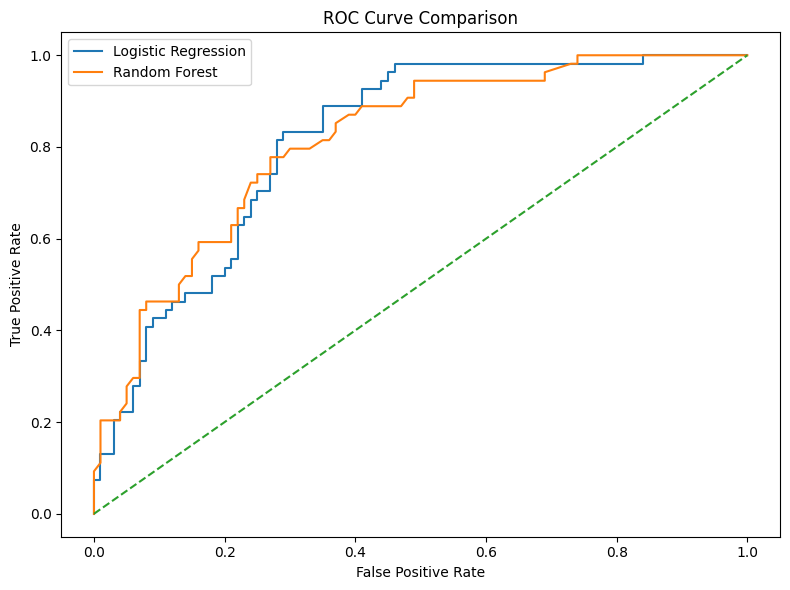

In [11]:
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

plt.figure(figsize=(8,6))
plt.plot(fpr_lr, tpr_lr, label="Logistic Regression")
plt.plot(fpr_rf, tpr_rf, label="Random Forest")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.tight_layout()
plt.savefig("../04_Exports/visuals/roc_comparison.png", dpi=300)
plt.show()


In [12]:
import joblib

joblib.dump(rf, "../03_Models/random_forest_diabetes.pkl")
joblib.dump(scaler, "../03_Models/scaler.pkl")

print("Model and scaler saved")


Model and scaler saved


In [13]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    roc_auc_score
)
import pandas as pd


In [14]:
globals().keys()


dict_keys(['__name__', '__doc__', '__package__', '__loader__', '__spec__', '__builtin__', '__builtins__', '_ih', '_oh', '_dh', 'In', 'Out', 'get_ipython', 'exit', 'quit', 'open', '_', '__', '___', '__session__', '_i', '_ii', '_iii', '_i1', '_i2', 'pd', 'np', 'train_test_split', 'StandardScaler', 'LogisticRegression', 'RandomForestClassifier', 'accuracy_score', 'classification_report', 'roc_auc_score', 'roc_curve', 'plt', '_i3', 'df', '_3', '_i4', 'X', 'y', '_4', '_i5', 'X_train', 'X_test', 'y_train', 'y_test', '_i6', 'scaler', 'X_train_scaled', 'X_test_scaled', '_i7', 'log_reg', '_7', '_i8', 'y_pred_lr', 'y_prob_lr', '_i9', 'rf', '_9', '_i10', 'y_pred_rf', 'y_prob_rf', '_i11', 'fpr_lr', 'tpr_lr', 'fpr_rf', 'tpr_rf', '_i12', 'joblib', '_i13', 'precision_score', 'recall_score', '_i14'])

In [15]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score
import pandas as pd


In [16]:
lr_metrics = {
    "Model": "Logistic Regression",
    "Accuracy": accuracy_score(y_test, y_pred_lr),
    "Precision": precision_score(y_test, y_pred_lr),
    "Recall": recall_score(y_test, y_pred_lr),
    "ROC_AUC": roc_auc_score(y_test, y_prob_lr)
}


In [17]:
rf_metrics = {
    "Model": "Random Forest",
    "Accuracy": accuracy_score(y_test, y_pred_rf),
    "Precision": precision_score(y_test, y_pred_rf),
    "Recall": recall_score(y_test, y_pred_rf),
    "ROC_AUC": roc_auc_score(y_test, y_prob_rf)
}


In [18]:
comparison_df = pd.DataFrame([lr_metrics, rf_metrics])
comparison_df


,Model,Accuracy,Precision,Recall,ROC_AUC
0,Logistic Regression,0.707792,0.600000,0.500000,0.815185
1,Random Forest,0.746753,0.653061,0.592593,0.813981


In [19]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
}).sort_values(by="Importance", ascending=False)

feature_importance


,Feature,Importance
1,Glucose,0.268128
5,BMI,0.160380
7,Age,0.127067
6,DiabetesPedigreeFunction,0.123448
2,BloodPressure,0.089140
0,Pregnancies,0.082398
4,Insulin,0.075549
3,SkinThickness,0.073892


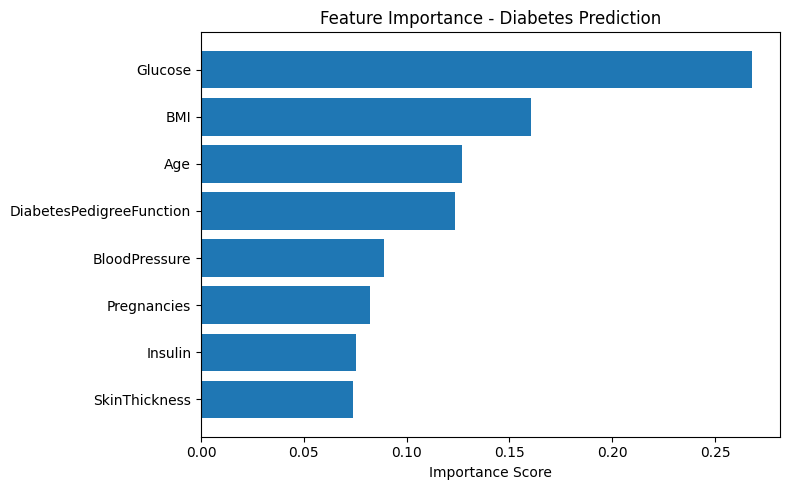

In [20]:
plt.figure(figsize=(8, 5))
plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)
plt.gca().invert_yaxis()
plt.title("Feature Importance - Diabetes Prediction")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()


In [21]:
results_df = X_test.copy()

results_df["Actual_Outcome"] = y_test.values
results_df["Predicted_Outcome"] = y_pred_rf
results_df["Diabetes_Risk_Probability"] = y_prob_rf

results_df.head()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Actual_Outcome,Predicted_Outcome,Diabetes_Risk_Probability
44,7,159,64,23,30.5,27.4,0.294,40,0,1,0.675
672,10,68,106,23,49.0,35.5,0.285,47,0,0,0.200
700,2,122,76,27,200.0,35.9,0.483,26,0,0,0.070
630,7,114,64,23,30.5,27.4,0.732,34,1,0,0.305
81,2,74,72,23,30.5,32.0,0.102,22,0,0,0.060


In [22]:
results_df["Actual_Label"] = results_df["Actual_Outcome"].map({
    0: "No Diabetes",
    1: "Diabetes"
})

results_df["Predicted_Label"] = results_df["Predicted_Outcome"].map({
    0: "No Diabetes",
    1: "Diabetes"
})


In [23]:
def risk_category(prob):
    if prob < 0.3:
        return "Low Risk"
    elif prob < 0.6:
        return "Medium Risk"
    else:
        return "High Risk"

results_df["Risk_Category"] = results_df["Diabetes_Risk_Probability"].apply(risk_category)



In [24]:
results_df.to_csv(
    "../04_Exports/diabetes_predictions_for_powerbi.csv",
    index=False
)


In [25]:
import os
os.listdir("../04_Exports")


['diabetes_predictions_for_powerbi.csv', 'visuals']

In [26]:
pip install shap


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [33]:
import shap


In [34]:
explainer = shap.TreeExplainer(rf)


In [35]:
shap_values = explainer.shap_values(X_test)

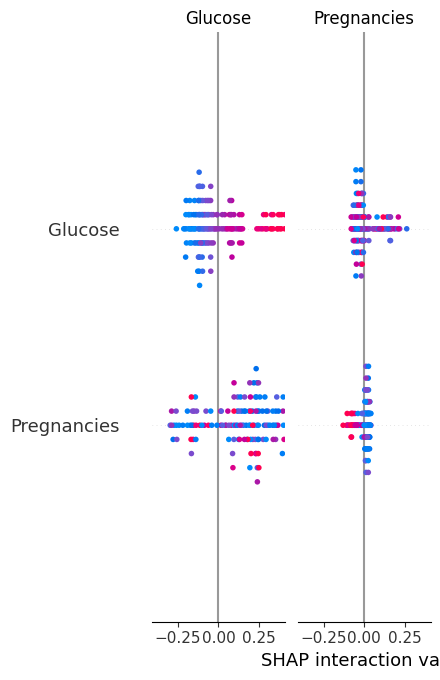

In [37]:
shap.summary_plot(shap_values, X_test)

<Figure size 640x480 with 0 Axes>

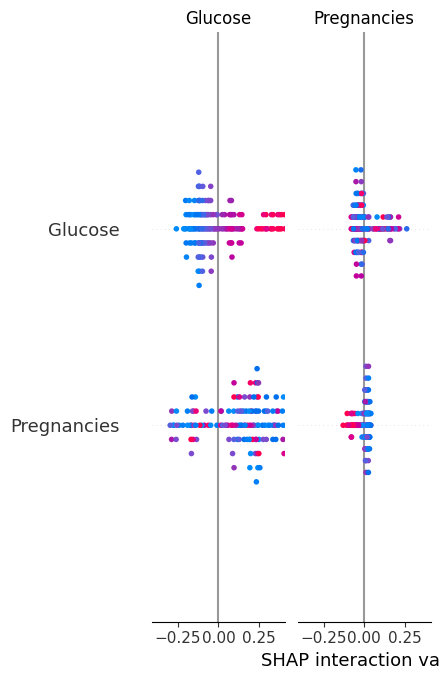

In [38]:
import matplotlib.pyplot as plt

plt.figure()
shap.summary_plot(shap_values, X_test, show=False)

plt.savefig("../04_Exports/visuals/shap_summary.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

In [ ]:
### Model Explainability with SHAP

To improve transparency and interpretability of the AI model,
SHAP (SHapley Additive exPlanations) was used.

The SHAP summary plot shows the contribution of each feature
to the model's predictions.

Results indicate that:

• Glucose level is the most influential predictor of diabetes.
• BMI and Age also strongly impact predictions.
• Other clinical indicators such as Blood Pressure and Insulin
  contribute moderately.

These findings align with established medical knowledge
regarding diabetes risk factors.


In [39]:
results = X_test.copy()

results["Actual"] = y_test
results["Prediction"] = y_pred_rf
results["Probability"] = y_prob_rf

results.to_csv("../04_Exports/predictions.csv", index=False)

In [40]:
import pandas as pd

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
1,Glucose,0.268128
5,BMI,0.160380
7,Age,0.127067
6,DiabetesPedigreeFunction,0.123448
2,BloodPressure,0.089140
0,Pregnancies,0.082398
4,Insulin,0.075549
3,SkinThickness,0.073892


In [41]:
feature_importance.to_csv(
    "../04_Exports/feature_importance.csv",
    index=False
)

print("Feature importance exported successfully!")

Feature importance exported successfully!
